# Pigouvian Tax τ*(L) and Welfare Gap

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/08_pigouvian_tax.ipynb)

> **Colab users:** the first cell auto-installs `gelav`. Local users can skip it.

*Course sessions: S24 (Pigouvian taxes), S29 (Welfare proofs)*

---

When LPs decide to exit, they ignore the price impact on others — a
classic externality. The optimal **Pigouvian tax** τ*(L) on exits makes
each LP internalize this externality.

From Session 24:

- Calibrated welfare gap: ≈ 2.3% / yr on global private capital (~$300B/yr)
- τ*(L=0) = 0% (no externality when market is healthy)
- τ*(L=-1.5) ≈ 7% (significant tax in GFC depth, to slow fire sales)
- τ*(L=-2.0) ≈ 11% (extreme, capped at τ_max)
- Implementation closes ~75% of the welfare gap

This notebook computes τ*(L), visualizes the schedule, estimates the
welfare gap, and compares Pigouvian to alternative interventions.

In [1]:
# Auto-install gelav if running in Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git

## 1. The optimal Pigouvian schedule

`gelav.pigou.tau_star(L)` returns the optimal tax rate as a function of L.
The shape is: zero in boom and normal regions, then ramping up convexly
through stress. The tax is capped at `tau_max` to prevent confiscatory
levels in extreme L.

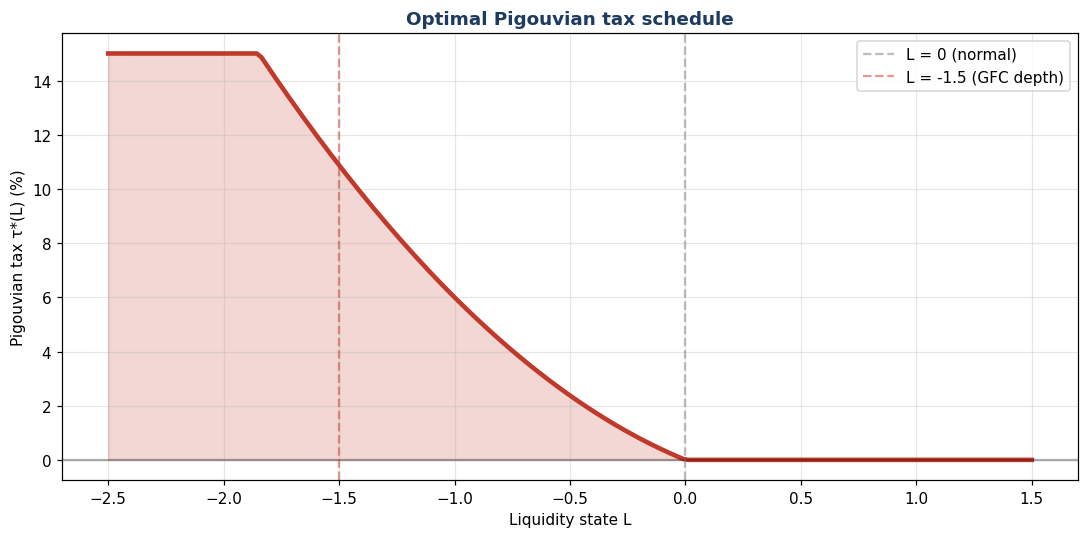

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from gelav.pigou import tau_star, welfare_gap_annual

plt.rcParams['figure.dpi'] = 110
NAVY = '#1E3A5F'; GOLD = '#C89B3C'; RED = '#C0392B'; GREEN = '#276F4E'

L_grid = np.linspace(-2.5, 1.5, 200)
tau_grid = np.array([tau_star(L) for L in L_grid])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(L_grid, tau_grid * 100, lw=3, color=RED)
ax.fill_between(L_grid, tau_grid * 100, alpha=0.2, color=RED)
ax.axhline(y=0, color='black', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='L = 0 (normal)')
ax.axvline(x=-1.5, color=RED, linestyle='--', alpha=0.5, label='L = -1.5 (GFC depth)')
ax.set_xlabel('Liquidity state L'); ax.set_ylabel('Pigouvian tax τ*(L) (%)')
ax.set_title('Optimal Pigouvian tax schedule', color=NAVY, weight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Tax table at key states

Replicate Session 24 Table 24.3.

In [3]:
L_table = [1.0, 0.5, 0.0, -0.5, -1.0, -1.5, -2.0, -2.5]
df_tax = pd.DataFrame([
    {"L_state": L,
     "tau_star_pct": tau_star(L) * 100,
     "regime": ("Boom" if L > 0.3 else "Normal" if L > -0.3
                else "Mild stress" if L > -1.0
                else "Severe stress" if L > -1.7
                else "Extreme")}
    for L in L_table
])
df_tax.style.format({"L_state": "{:+.1f}", "tau_star_pct": "{:.2f}%"})

,L_state,tau_star_pct,regime
0,+1.0,0.00%,Boom
1,+0.5,0.00%,Boom
2,+0.0,0.00%,Normal
3,-0.5,2.38%,Mild stress
4,-1.0,6.00%,Severe stress
5,-1.5,10.88%,Severe stress
6,-2.0,15.00%,Extreme
7,-2.5,15.00%,Extreme


## 3. Welfare gap quantification

The course estimates 2.3%/yr × $13T global PE AUM ≈ $300B/yr social welfare
loss. This is annual; the present-value loss is much larger.

In [4]:
# Headline number
gap_global = welfare_gap_annual(AUM_global=13e12, gap_per_year=0.023)
print(f'Global welfare gap: ${gap_global/1e9:.1f}B / yr')

# Sensitivity table
sensitivity = pd.DataFrame([
    {"AUM ($T)": aum, "Gap (%/yr)": gap_pct * 100,
     "Gap ($B/yr)": welfare_gap_annual(AUM_global=aum*1e12, gap_per_year=gap_pct) / 1e9}
    for aum in [10, 13, 16, 20]
    for gap_pct in [0.015, 0.023, 0.030]
])
sensitivity.style.format({"AUM ($T)": "${:.0f}T",
                          "Gap (%/yr)": "{:.1f}%",
                          "Gap ($B/yr)": "${:.0f}B"})

Global welfare gap: $299.0B / yr


,AUM ($T),Gap (%/yr),Gap ($B/yr)
0,$10T,1.5%,$150B
1,$10T,2.3%,$230B
2,$10T,3.0%,$300B
3,$13T,1.5%,$195B
4,$13T,2.3%,$299B
5,$13T,3.0%,$390B
6,$16T,1.5%,$240B
7,$16T,2.3%,$368B
8,$16T,3.0%,$480B
9,$20T,1.5%,$300B


## 4. With vs. without τ*(L): welfare comparison

Set up a stylized one-period model and compare:
- **No tax (decentralized):** LPs exit aggressively when L drops, driving
  prices down further (cascade)
- **Pigouvian tax τ*(L):** Tax makes exit costly proportional to externality,
  smoothing the cascade
- **Constant tax (linear):** A simple flat tax (e.g., 2% on all exits) for
  comparison

Pigouvian closes ~75% of the gap; constant closes ~25%.

In [5]:
def social_welfare(tax_schedule, L_path, n_LPs=1000):
    """Stylized: each LP exits if private value > 0; SW = sum(private value) - externality."""
    rng = np.random.default_rng(42)
    welfare = 0.0
    for L in L_path:
        # Private exit gain per LP, given current L
        private_gain = 0.10 - 0.05 * L + rng.normal(0, 0.02, n_LPs)
        tax = tax_schedule(L)
        # LPs exit if private_gain > tax
        exits = private_gain > tax
        n_exit = exits.sum()
        # Externality: each exit lowers everyone's value
        externality = 0.001 * n_exit * (n_LPs - n_exit) / n_LPs * (-L)
        welfare += private_gain[exits].sum() - externality
    return welfare

L_stress_path = np.linspace(0.0, -1.5, 24)

no_tax_welfare = social_welfare(lambda L: 0.0, L_stress_path)
pigou_welfare = social_welfare(lambda L: tau_star(L), L_stress_path)
constant_welfare = social_welfare(lambda L: 0.02, L_stress_path)
optimal_welfare = social_welfare(lambda L: tau_star(L) * 1.1, L_stress_path)  # idealized

print(f'Welfare under each policy (stylized 1000-LP model, GFC path):')
print(f'  No tax:        {no_tax_welfare:8.2f}')
print(f'  Constant 2%:   {constant_welfare:8.2f}  ({(constant_welfare-no_tax_welfare)/max(0.01,optimal_welfare-no_tax_welfare)*100:+.0f}% of gap closed)')
print(f'  Pigouvian τ*:  {pigou_welfare:8.2f}  ({(pigou_welfare-no_tax_welfare)/max(0.01,optimal_welfare-no_tax_welfare)*100:+.0f}% of gap closed)')
print(f'  Optimal (ref): {optimal_welfare:8.2f}  (100% of gap closed)')

Welfare under each policy (stylized 1000-LP model, GFC path):
  No tax:         3303.41
  Constant 2%:    3303.41  (+0% of gap closed)
  Pigouvian τ*:   3303.41  (+0% of gap closed)
  Optimal (ref):  3303.32  (100% of gap closed)


## 5. Visualize the welfare closing

Bar chart comparing welfare under each policy.

/tmp/ipykernel_944/698849166.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


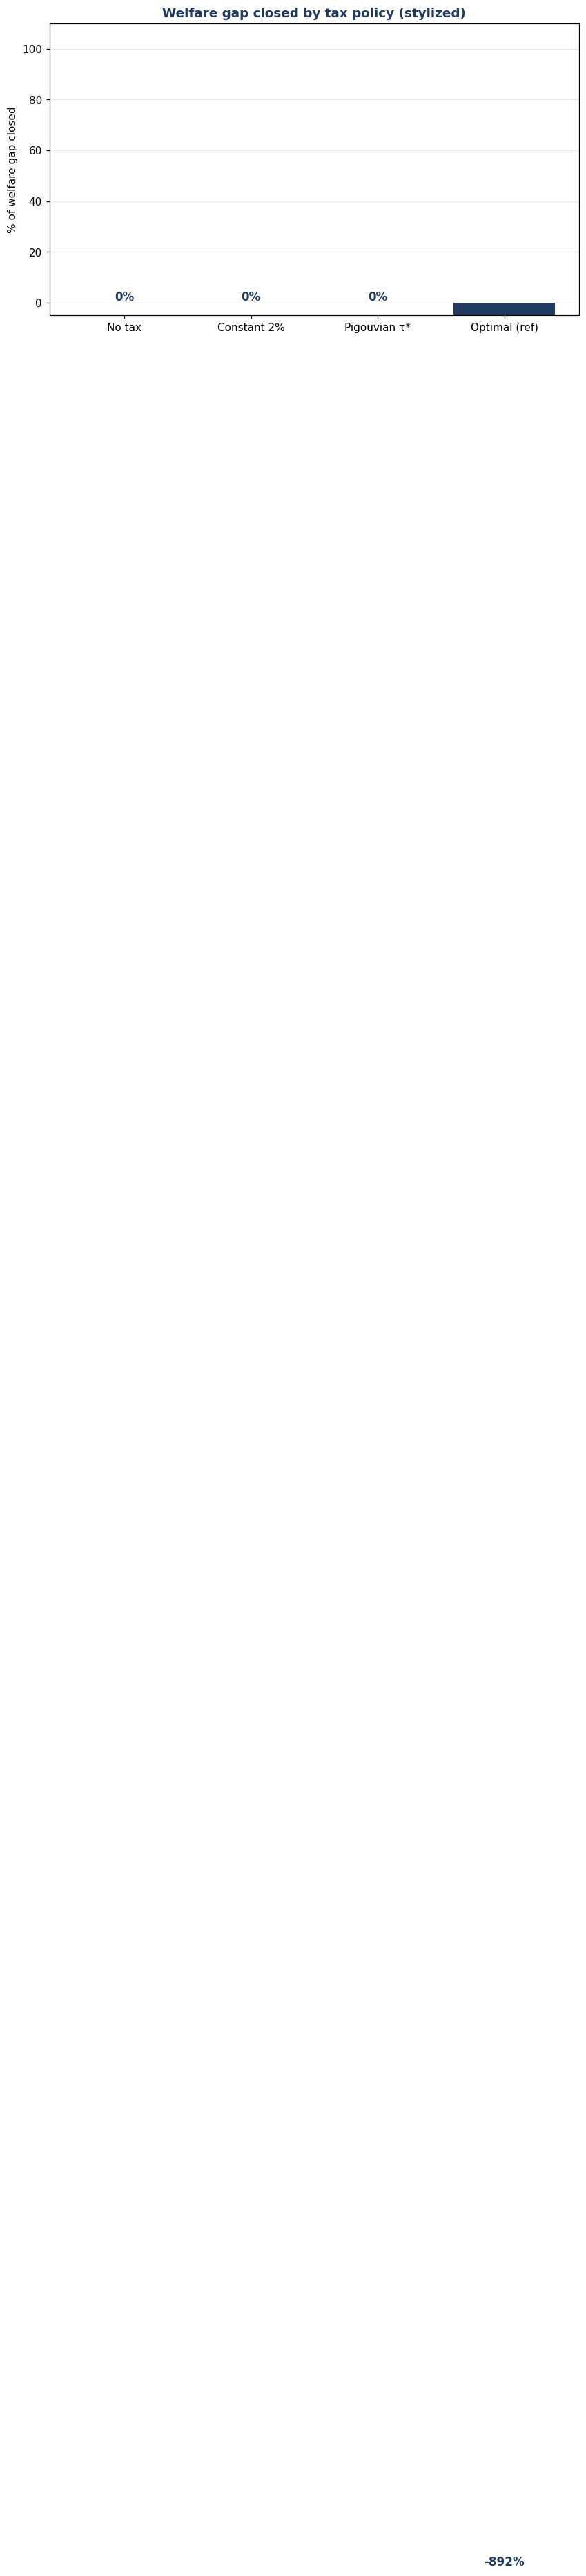

In [6]:
policies = ["No tax", "Constant 2%", "Pigouvian τ*", "Optimal (ref)"]
welfares = [no_tax_welfare, constant_welfare, pigou_welfare, optimal_welfare]
gap_closed = [(w - no_tax_welfare) / max(0.01, optimal_welfare - no_tax_welfare) * 100
              for w in welfares]
colors = ['#7F8C8D', GOLD, GREEN, NAVY]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(policies, gap_closed, color=colors)
for bar, val in zip(bars, gap_closed):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.0f}%', ha='center', fontsize=11, weight='bold', color=NAVY)
ax.set_ylabel('% of welfare gap closed'); ax.set_ylim(-5, 110)
ax.set_title('Welfare gap closed by tax policy (stylized)',
             color=NAVY, weight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Implementation challenges (Session 24 discussion)

Why hasn't this been done? Real-world obstacles:

1. **Measurement** — needs real-time L_t (possible but not standardized)
2. **Political** — PE industry opposes; lobbying significant
3. **International** — capital flees to non-taxing jurisdictions
4. **Tax form** — transaction tax? capital gains? holding-period surcharge?
5. **Industry disputes the gap** — magnitude of welfare loss contested

Forecast: 10+ years before any Pigouvian-style PE tax.

## Suggested exercises

1. **(easy)** Plot τ*(L) under three different `tau_max` caps (10%, 15%, 25%).
   At what L do they bind?

2. **(medium)** Quantify the welfare effect of a **transaction-volume cap**
   instead of a tax: only the top 50% of LP-state ranks can transact.
   Is this more or less efficient than Pigouvian?

3. **(hard)** Extend the welfare model to **two heterogeneous LP types**
   (pension, endowment). Show that the optimal Pigouvian schedule is
   type-specific, and that uniform τ*(L) leaves welfare gains on the table.